In [1]:
# Reads and plots from a pickled file containing pressure field data as generated by Rust files.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

leading_string = "pos_test_refcoeff_0.001"

import pickle
file = open(f"../rust/out/{leading_string}_fields.pickle", "rb")
field = pickle.load(file)

file = open(f"../rust/out/{leading_string}_times.pickle", "rb")
time = pickle.load(file)

print(np.shape(field))
print(np.shape(time))

(11, 160, 1, 160, 2)
(11,)


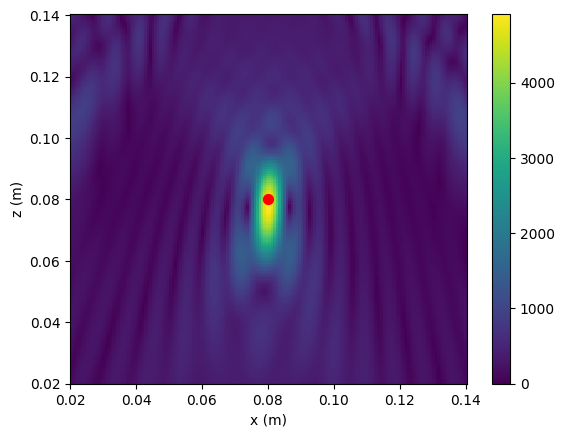

In [2]:
# Assume:
# field: list/array of subfields
# time: array of same length as field

fig, ax = plt.subplots()

# --- initialize with first frame ---
subfield0 = field[0]
F0 = np.array(subfield0)
F0 = F0[:, :, :, 0] + 1j * F0[:, :, :, 1]
norm0 = np.abs(F0)

N = F0.shape[0]
x = np.linspace(0.020375, 0.14000028, N)
z = np.linspace(0.020375, 0.14000028, N)

mesh = ax.pcolormesh(
    x,
    z,
    norm0[:, 0, :].swapaxes(0, 1),
    vmin=0,
    vmax=np.max(norm0),
    shading="auto"
)

scatter = ax.scatter(0.08, 0.08, 50, c='r', marker='o')

cbar = fig.colorbar(mesh, ax=ax)
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")

title = ax.set_title("")

# --- update function ---
def update(index):
    subfield = field[index]

    F = np.array(subfield)
    F = F[:, :, :, 0] + 1j * F[:, :, :, 1]
    norm = np.abs(F)

    # update colormesh data
    mesh.set_array(norm[:, 0, :].swapaxes(0, 1).ravel())
    mesh.set_clim(0, np.max(norm))

    # update scatter position
    scatter.set_offsets([[0.08 + index * 0.0025, 0.08]])

    # update title with time
    title.set_text(
        f"Un-normalized pressure distribution\n"
        f"y = 0.08, t = {time[index]:.3f}"
    )

    return mesh, scatter, title

# --- create animation ---
ani = FuncAnimation(
    fig,
    update,
    frames=len(field),
    interval=50,   # ms between frames
    blit=False
)

plt.show()

ani.save(f"{leading_string}.mp4", dpi=200)

(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)
(80, 1, 80)


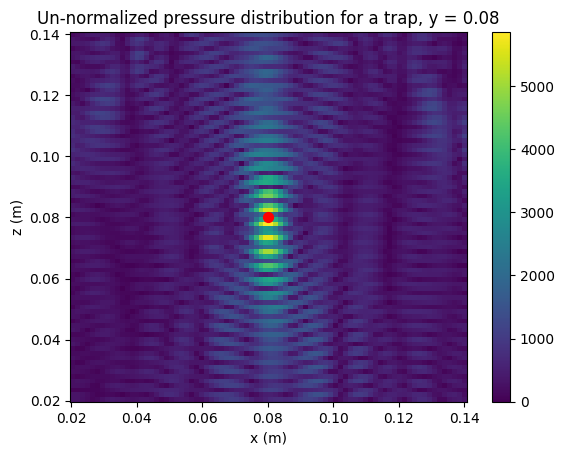

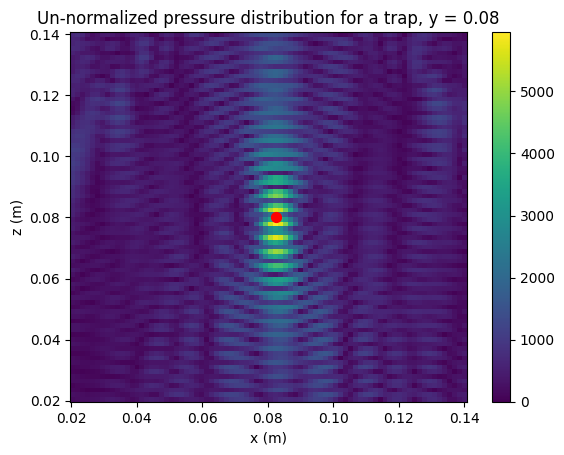

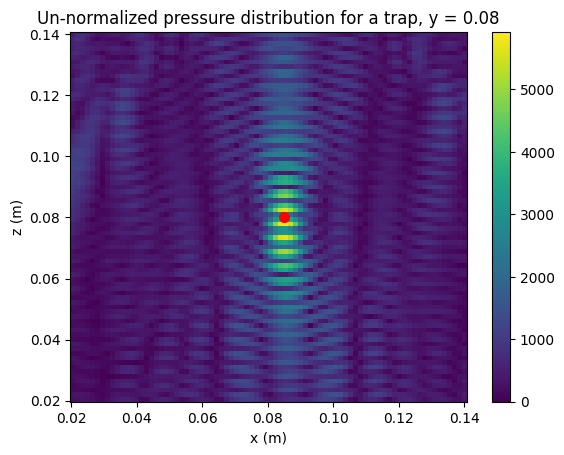

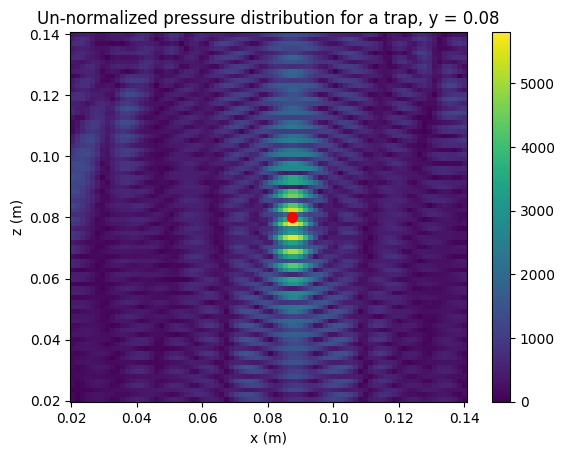

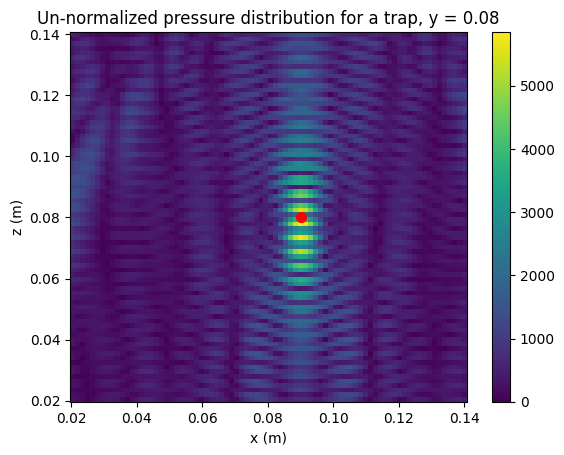

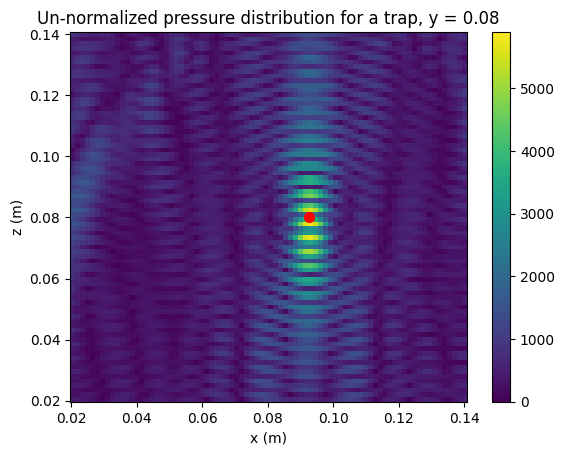

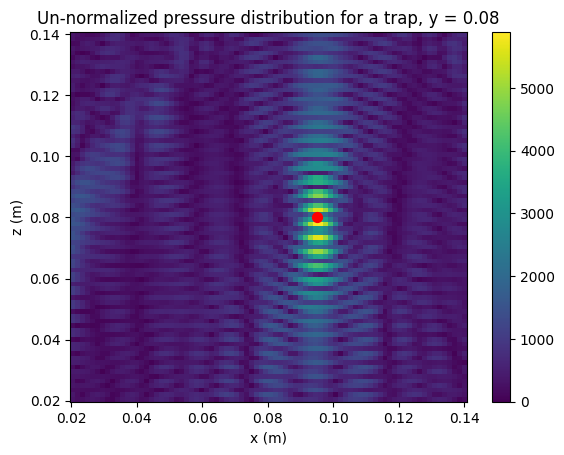

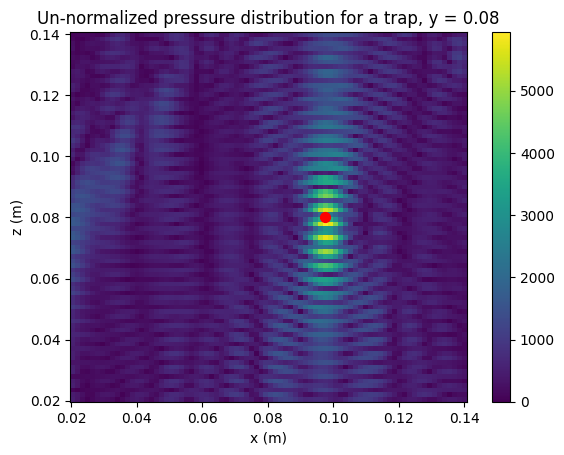

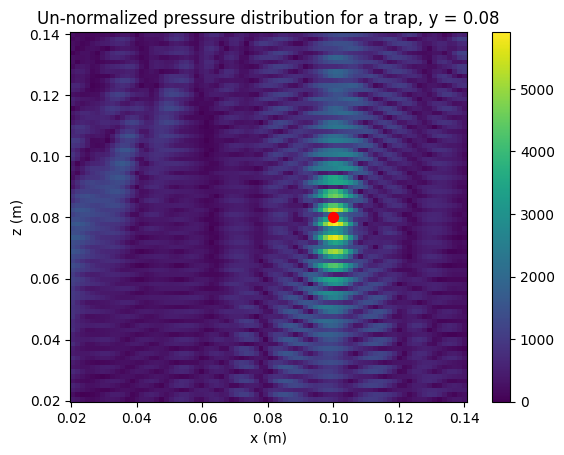

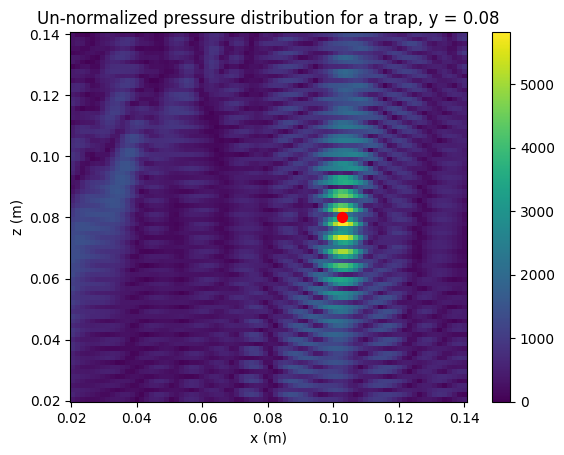

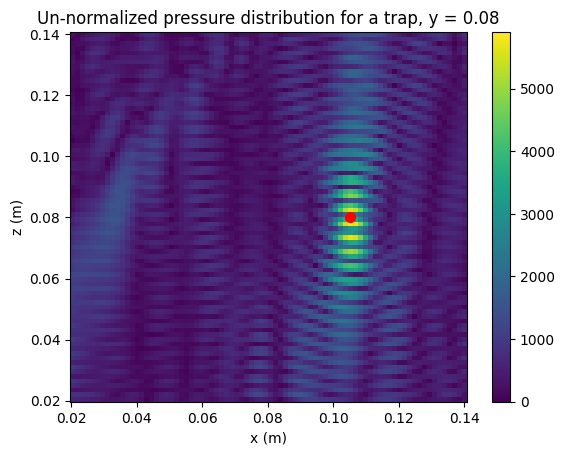

In [ ]:
for (index, subfield) in enumerate(field):
    F = np.array(subfield)

    F = F[:, :, :, 0] + 1j * F[:, :, :, 1]
    # norm = np.abs(F)/np.max(np.abs(F))
    norm = np.abs(F)
    phase = np.angle(F)

    print(F.shape)

    N = F.shape[0]  # This won't always be the case.

    plt.figure()

    mesh = plt.pcolormesh(np.linspace(0.020375, 0.14000028, N), np.linspace(0.020375, 0.14000028, N), norm[:, 0, :].swapaxes(0, 1), vmax=np.max(norm[:, 0, :]), vmin=0)
    plt.scatter(0.08+index*0.0025, 0.08, 50, c='r', marker='o') # Somewhat hard-coded
    plt.colorbar(mesh)
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(f"Un-normalized pressure distribution for a trap, y = 0.08")